In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lamthicucb2203709/cnn1d-ckpt/optuna_study_cnn1d_37ft.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/train_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/full_dataset_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_minmax_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/class_weights_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/feature_columns_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/audit_report_p3.2.json
/kaggle/input/datasets/rsnngo/37ft-thang3737/val_minmax_p3.2.parquet
/kaggle/input/datasets/rsnngo/37ft-thang3737/scaler_standard_p3.2.pkl
/kaggle/input/datasets/rsnngo/37ft-thang3737/test_p3.2.parquet
/kaggle/input/datasets/rsnngo/37

In [2]:
# ╔══════════════════════════════════════════════════════════╗
# ║              CELL 1 — CẤU HÌNH & IMPORT                 ║
# ╚══════════════════════════════════════════════════════════╝
!pip install -q optuna

import os, json, time, gc, pickle, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, backend as K
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, roc_auc_score,
    f1_score, accuracy_score, precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Đường dẫn ──────────────────────────────────────────────
TRAIN_PATH = "/kaggle/input/datasets/rsnngo/37ft-thang3737/train_standard_p3.2.parquet"
VAL_PATH   = "/kaggle/input/datasets/rsnngo/37ft-thang3737/val_standard_p3.2.parquet"
TEST_PATH  = "/kaggle/input/datasets/rsnngo/37ft-thang3737/test_standard_p3.2.parquet"
OUTPUT_DIR = "/kaggle/working/"
TARGET_COL = "label"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── Checkpoint Optuna ─────────────────────────────────────
OPTUNA_STUDY_PATH = os.path.join(OUTPUT_DIR, 'optuna_study_cnn1d_37ft.pkl')

LABEL_NAMES = {
    0: 'Benign', 1: 'DDoS',  2: 'DoS',      3: 'BruteForce',
    4: 'Spoofing', 5: 'Recon', 6: 'Web-Based', 7: 'Mirai'
}

# ── Kiến trúc CNN1D ──────────────────────────────────────
CONV_FILTERS = [256, 256, 256]
KERNEL_SIZE = 3
POOL_SIZE = 2
DROPOUT_RATE = 0.1

# ── Optuna search space ──────────────────────────────────
OPTUNA_N_TRIALS   = 20
OPTUNA_EPOCHS     = 50
OPTUNA_LR_LOW     = 1e-5
OPTUNA_LR_HIGH    = 0.3
OPTUNA_BS_CHOICES = [64, 100, 128, 256, 512]

# ── Train chính thức ────────────────────────────────────
FINAL_MAX_EPOCHS = 50
RANDOM_SEED      = 42

# ── Timeout ─────────────────────────────────────────────
TIMEOUT_S = 3600 * 12          # 12 giờ
T_START   = time.time()
DEADLINE  = T_START + TIMEOUT_S

# ── Seed ──────────────────────────────────────────────────
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print('=' * 58)
print('  CNN1D [256,256,256] Teacher Model + Optuna — CICIoT2023 (8 classes)')
print('=' * 58)
print(f"  TensorFlow version  : {tf.__version__}")
print(f"  GPU available       : {tf.config.list_physical_devices('GPU')}")
print()
print('  [Kiến trúc — CNN1D]')
print(f'  Conv1D filters      : {CONV_FILTERS}, kernel_size={KERNEL_SIZE}')
print(f'  MaxPooling1D        : pool_size={POOL_SIZE} (sau mỗi Conv)')
print(f'  BatchNormalization  : sau mỗi Conv+Pool')
print(f'  Dropout {DROPOUT_RATE} : chỉ 1 lần sau Flatten (trước Dense output)')
print( '  Optimizer           : Adam | loss: sparse_categorical_crossentropy')
print()
print(f'  n_trials            : {OPTUNA_N_TRIALS}')
print(f'  epoch/trial         : {OPTUNA_EPOCHS}  (không early stop)')
print(f'  lr                  : log-uniform [{OPTUNA_LR_LOW}, {OPTUNA_LR_HIGH}]')
print(f'  batch_size          : categorical {OPTUNA_BS_CHOICES}')
print( '  objective           : maximize val macro-F1')
print( '  pruner              : MedianPruner(n_startup_trials=3, n_warmup_steps=5)')
print()
print(f'  Train chính thức    : {FINAL_MAX_EPOCHS} epoch (lưu best epoch theo val loss thấp nhất)')
print('=' * 58)
print(f'  TIMEOUT             : {TIMEOUT_S/3600:.1f} giờ (deadline tính từ lúc kernel start)')

  CNN1D [256,256,256] Teacher Model + Optuna — CICIoT2023 (8 classes)
  TensorFlow version  : 2.20.0
  GPU available       : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

  [Kiến trúc — CNN1D]
  Conv1D filters      : [256, 256, 256], kernel_size=3
  MaxPooling1D        : pool_size=2 (sau mỗi Conv)
  BatchNormalization  : sau mỗi Conv+Pool
  Dropout 0.1 : chỉ 1 lần sau Flatten (trước Dense output)
  Optimizer           : Adam | loss: sparse_categorical_crossentropy

  n_trials            : 20
  epoch/trial         : 50  (không early stop)
  lr                  : log-uniform [1e-05, 0.3]
  batch_size          : categorical [64, 100, 128, 256, 512]
  objective           : maximize val macro-F1
  pruner              : MedianPruner(n_startup_trials=3, n_warmup_steps=5)

  Train chính thức    : 50 epoch (lưu best epoch theo val loss thấp nhất)
  TIMEOUT             : 12.0 giờ (deadline tính từ lúc kernel 

In [3]:
# ╔══════════════════════════════════════════════════════════╗
# ║              CELL 2 — LOAD DATA                         ║
# ║  Load và reshape cho CNN1D: (samples, features, 1)      ║
# ╚══════════════════════════════════════════════════════════╝
df_train = pd.read_parquet(TRAIN_PATH)
df_val   = pd.read_parquet(VAL_PATH)
df_test  = pd.read_parquet(TEST_PATH)

feature_cols = [c for c in df_train.columns if c != TARGET_COL]

X_train = df_train[feature_cols].values.astype(np.float32)
y_train = df_train[TARGET_COL].values.astype(np.int32)
X_val   = df_val[feature_cols].values.astype(np.float32)
y_val   = df_val[TARGET_COL].values.astype(np.int32)
X_test  = df_test[feature_cols].values.astype(np.float32)
y_test  = df_test[TARGET_COL].values.astype(np.int32)

NUM_CLASSES  = int(np.max(y_train)) + 1
NUM_FEATURES = X_train.shape[1]

# Reshape cho CNN1D: (samples, features, 1)
X_train = X_train.reshape(-1, NUM_FEATURES, 1)
X_val   = X_val.reshape(-1, NUM_FEATURES, 1)
X_test  = X_test.reshape(-1, NUM_FEATURES, 1)

# Lưu metadata
with open(f"{OUTPUT_DIR}metadata.json", "w") as f:
    json.dump({"feature_cols": feature_cols, "target_col": TARGET_COL,
               "num_classes": NUM_CLASSES, "num_features": NUM_FEATURES}, f, indent=4)

print(f"Train : {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")
print(f"Num classes: {NUM_CLASSES} | Num features: {NUM_FEATURES}")
print("\nPhân bố lớp (train):")
for c in range(NUM_CLASSES):
    n = int((y_train == c).sum())
    print(f"  {c} {LABEL_NAMES.get(c, c):<11}: {n:>9,}  ({n/len(y_train)*100:5.2f}%)")

del df_train, df_val, df_test
gc.collect()

Train : (4468344, 37, 1) | Val: (1117087, 37, 1) | Test: (1396358, 37, 1)
Num classes: 8 | Num features: 37

Phân bố lớp (train):
  0 Benign     :   670,231  (15.00%)
  1 DDoS       : 1,916,729  (42.90%)
  2 DoS        :   619,802  (13.87%)
  3 BruteForce :     8,013  ( 0.18%)
  4 Spoofing   :   278,953  ( 6.24%)
  5 Recon      :   383,443  ( 8.58%)
  6 Web-Based  :    15,173  ( 0.34%)
  7 Mirai      :   576,000  (12.89%)


33

In [4]:
# ╔══════════════════════════════════════════════════════════╗
# ║   CELL 3 — KIẾN TRÚC CNN1D [256,256,256]               ║
# ║   Conv1D + MaxPooling + BN mỗi layer, Dropout trước    ║
# ║   Flatten (Dropout → Flatten → Dense)                  ║
# ╚══════════════════════════════════════════════════════════╝
def build_cnn1d_model(learning_rate, input_shape, num_classes):
    """
    Xây dựng CNN1D:
    - 3 layer Conv1D (filters=256, kernel=3, padding='same')
    - Sau mỗi Conv: MaxPooling1D(pool_size=2) + BatchNormalization
    - Cuối: Dropout(0.1) → Flatten → Dense(8, softmax)
    """
    inp = layers.Input(shape=input_shape)  # (features, 1)
    x = inp
    for filters in CONV_FILTERS:
        x = layers.Conv1D(filters, kernel_size=KERNEL_SIZE, padding='same', activation='relu')(x)
        x = layers.MaxPooling1D(pool_size=POOL_SIZE)(x)
        x = layers.BatchNormalization()(x)
    # Dropout trước khi Flatten
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Flatten()(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

_m = build_cnn1d_model(1e-3, (NUM_FEATURES, 1), NUM_CLASSES)
_m.summary()
print(f"\nTổng params: {_m.count_params():,}")
del _m
K.clear_session()
gc.collect()

I0000 00:00:1785218994.729964      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785218994.732633      22 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 37, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 37, 256)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 18, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 18, 256)        │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 9, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 9, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 9, 256)         │       196,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 256)         │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 256)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         8,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,024 (1.55 MB)

 Trainable params: 404,488 (1.54 MB)

 Non-trainable params: 1,536 (6.00 KB)


Tổng params: 406,024


0

In [5]:
# ╔══════════════════════════════════════════════════════════╗
# ║   CELL 4 — OPTUNA HYPERPARAMETER SEARCH                 ║
# ║   Pipeline giống DNN nhưng dùng model CNN1D             ║
# ╚══════════════════════════════════════════════════════════╝

class _OptunaPruneCallback(tf.keras.callbacks.Callback):
    def __init__(self, trial, X_val, y_val, eval_bs=1024):
        super().__init__()
        self.trial   = trial
        self.X_val   = X_val
        self.y_val   = y_val
        self.eval_bs = eval_bs
        self.last_f1 = 0.0

    def on_epoch_end(self, epoch, logs=None):
        val_proba = self.model.predict(self.X_val, batch_size=self.eval_bs, verbose=0)
        val_preds = np.argmax(val_proba, axis=1)
        macro_f1  = f1_score(self.y_val, val_preds, average='macro', zero_division=0)
        self.last_f1 = macro_f1
        self.trial.report(macro_f1, epoch + 1)
        if self.trial.should_prune():
            raise optuna.exceptions.TrialPruned()


def optuna_objective(trial):
    lr         = trial.suggest_float('lr', OPTUNA_LR_LOW, OPTUNA_LR_HIGH, log=True)
    batch_size = trial.suggest_categorical('batch_size', OPTUNA_BS_CHOICES)

    K.clear_session()
    model = build_cnn1d_model(lr, (NUM_FEATURES, 1), NUM_CLASSES)

    prune_cb = _OptunaPruneCallback(trial, X_val, y_val)

    try:
        model.fit(
            X_train, y_train,
            batch_size=batch_size,
            epochs=OPTUNA_EPOCHS,
            validation_data=(X_val, y_val),
            callbacks=[prune_cb],
            verbose=0
        )
        val_macro_f1 = prune_cb.last_f1
    finally:
        del model
        K.clear_session()
        gc.collect()

    return val_macro_f1


# ── Quản lý study với checkpoint ──────────────────────────
def _n_finished(st):
    return len([t for t in st.trials if t.state.is_finished()])

def _save_ckpt(st):
    tmp = OPTUNA_STUDY_PATH + '.tmp'
    with open(tmp, 'wb') as f:
        pickle.dump(st, f)
    os.replace(tmp, OPTUNA_STUDY_PATH)

def _find_input_checkpoint():
    for p in sorted(glob.glob('/kaggle/input/datasets/lamthicucb2203709/cnn1d-ckpt/optuna_study_cnn1d_37ft.pkl', recursive=True)):
        try:
            with open(p, 'rb') as f:
                obj = pickle.load(f)
            if isinstance(obj, optuna.study.Study):
                return p, obj
        except Exception:
            continue
    return None, None

# ── Nạp study ──────────────────────────────────────────────
study = None
if os.path.isfile(OPTUNA_STUDY_PATH):
    with open(OPTUNA_STUDY_PATH, 'rb') as f:
        study = pickle.load(f)
    print(f'[Optuna] Resume từ OUTPUT: {OPTUNA_STUDY_PATH}')
else:
    _p, _st = _find_input_checkpoint()
    if _st is not None:
        study = _st
        print(f'[Optuna] Resume từ INPUT: {_p}')

if study is None:
    sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
    pruner  = optuna.pruners.MedianPruner(n_startup_trials=3, n_warmup_steps=5)
    study   = optuna.create_study(direction='maximize',
                                  sampler=sampler, pruner=pruner)
    print(f'[Optuna] Tạo study MỚI — mục tiêu {OPTUNA_N_TRIALS} trials x {OPTUNA_EPOCHS} epoch/trial')

n_done      = _n_finished(study)
n_remaining = max(0, OPTUNA_N_TRIALS - n_done)
print(f'[Optuna] Đã xong {n_done}/{OPTUNA_N_TRIALS} trials — cần chạy thêm {n_remaining}')

_save_ckpt(study)   # đảm bảo có checkpoint ngay từ đầu

def _ckpt_deadline_cb(st, trial):
    _save_ckpt(st)
    left = DEADLINE - time.time()
    print(f'[Optuna] trial #{trial.number} {trial.state.name} — '
          f'{_n_finished(st)}/{OPTUNA_N_TRIALS} | còn {left/60:.1f} phút | checkpoint đã lưu')
    if time.time() >= DEADLINE:
        print('[Optuna] ⏰ Chạm DEADLINE → dừng sau trial này.')
        st.stop()

if n_remaining > 0:
    _budget = DEADLINE - time.time()
    if _budget > 0:
        t_optuna = time.time()
        study.optimize(optuna_objective,
                       n_trials=n_remaining,
                       timeout=_budget,
                       callbacks=[_ckpt_deadline_cb],
                       gc_after_trial=True,
                       show_progress_bar=True)
        print(f'[Optuna] Phiên này chạy {(time.time()-t_optuna)/60:.1f} phút')
    else:
        print('[Optuna] ⏰ Hết ngân sách thời gian trước khi kịp chạy trial nào.')

_save_ckpt(study)
n_done          = _n_finished(study)
OPTUNA_FINISHED = n_done >= OPTUNA_N_TRIALS
PIPELINE_CONTINUE = OPTUNA_FINISHED

print()
print('=' * 58)
if OPTUNA_FINISHED:
    print(f'[Optuna] ✓ HOÀN TẤT {n_done}/{OPTUNA_N_TRIALS} trials')
    print(f'  Checkpoint: {OPTUNA_STUDY_PATH}')
else:
    print(f'[Optuna] ⏸ DỪNG DO TIMEOUT — mới xong {n_done}/{OPTUNA_N_TRIALS} trials')
    print(f'  Checkpoint đã lưu: {OPTUNA_STUDY_PATH}')
    print('  → Các bước tiếp theo:')
    print(f'    1. Tải {os.path.basename(OPTUNA_STUDY_PATH)} từ Output của run này')
    print('    2. Upload làm dataset input (chỉ chứa 1 file .pkl này)')
    print('    3. Add dataset đó vào notebook rồi Run lại — study tự resume')
    print('  Các cell phía sau (viz / train / eval) sẽ TỰ ĐỘNG BỎ QUA ở run này.')
print('=' * 58)

if OPTUNA_FINISHED:
    best_params              = study.best_params
    best_val_macro_f1_optuna = study.best_value
    BEST_LR         = best_params['lr']
    BEST_BATCH_SIZE = best_params['batch_size']

    with open(f"{OUTPUT_DIR}best_params.json", "w") as f:
        json.dump(best_params, f, indent=4)

    print()
    print('=' * 58)
    print('  KẾT QUẢ OPTUNA SEARCH')
    print('=' * 58)
    print(f'  Best val macro-F1 : {best_val_macro_f1_optuna:.6f}')
    print(f'  lr                = {BEST_LR:.7f}')
    print(f'  batch_size        = {BEST_BATCH_SIZE}')
    print('=' * 58)
    print('\nTrain chính thức sẽ dùng các tham số này.')

[Optuna] Resume từ INPUT: /kaggle/input/datasets/lamthicucb2203709/cnn1d-ckpt/optuna_study_cnn1d_37ft.pkl
[Optuna] Đã xong 16/20 trials — cần chạy thêm 4


  0%|          | 0/4 [00:00<?, ?it/s]

I0000 00:00:1785219006.965589      82 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


[Optuna] trial #16 COMPLETE — 17/20 | còn 562.0 phút | checkpoint đã lưu
[Optuna] trial #17 COMPLETE — 18/20 | còn 404.7 phút | checkpoint đã lưu
[Optuna] trial #18 COMPLETE — 19/20 | còn 248.2 phút | checkpoint đã lưu
[Optuna] trial #19 PRUNED — 20/20 | còn 232.5 phút | checkpoint đã lưu
[Optuna] Phiên này chạy 487.3 phút

[Optuna] ✓ HOÀN TẤT 20/20 trials
  Checkpoint: /kaggle/working/optuna_study_cnn1d_37ft.pkl

  KẾT QUẢ OPTUNA SEARCH
  Best val macro-F1 : 0.686263
  lr                = 0.0000727
  batch_size        = 128

Train chính thức sẽ dùng các tham số này.


Completed trials : 11
Pruned trials    : 9
Best trial       : #16  macro-F1=0.686263


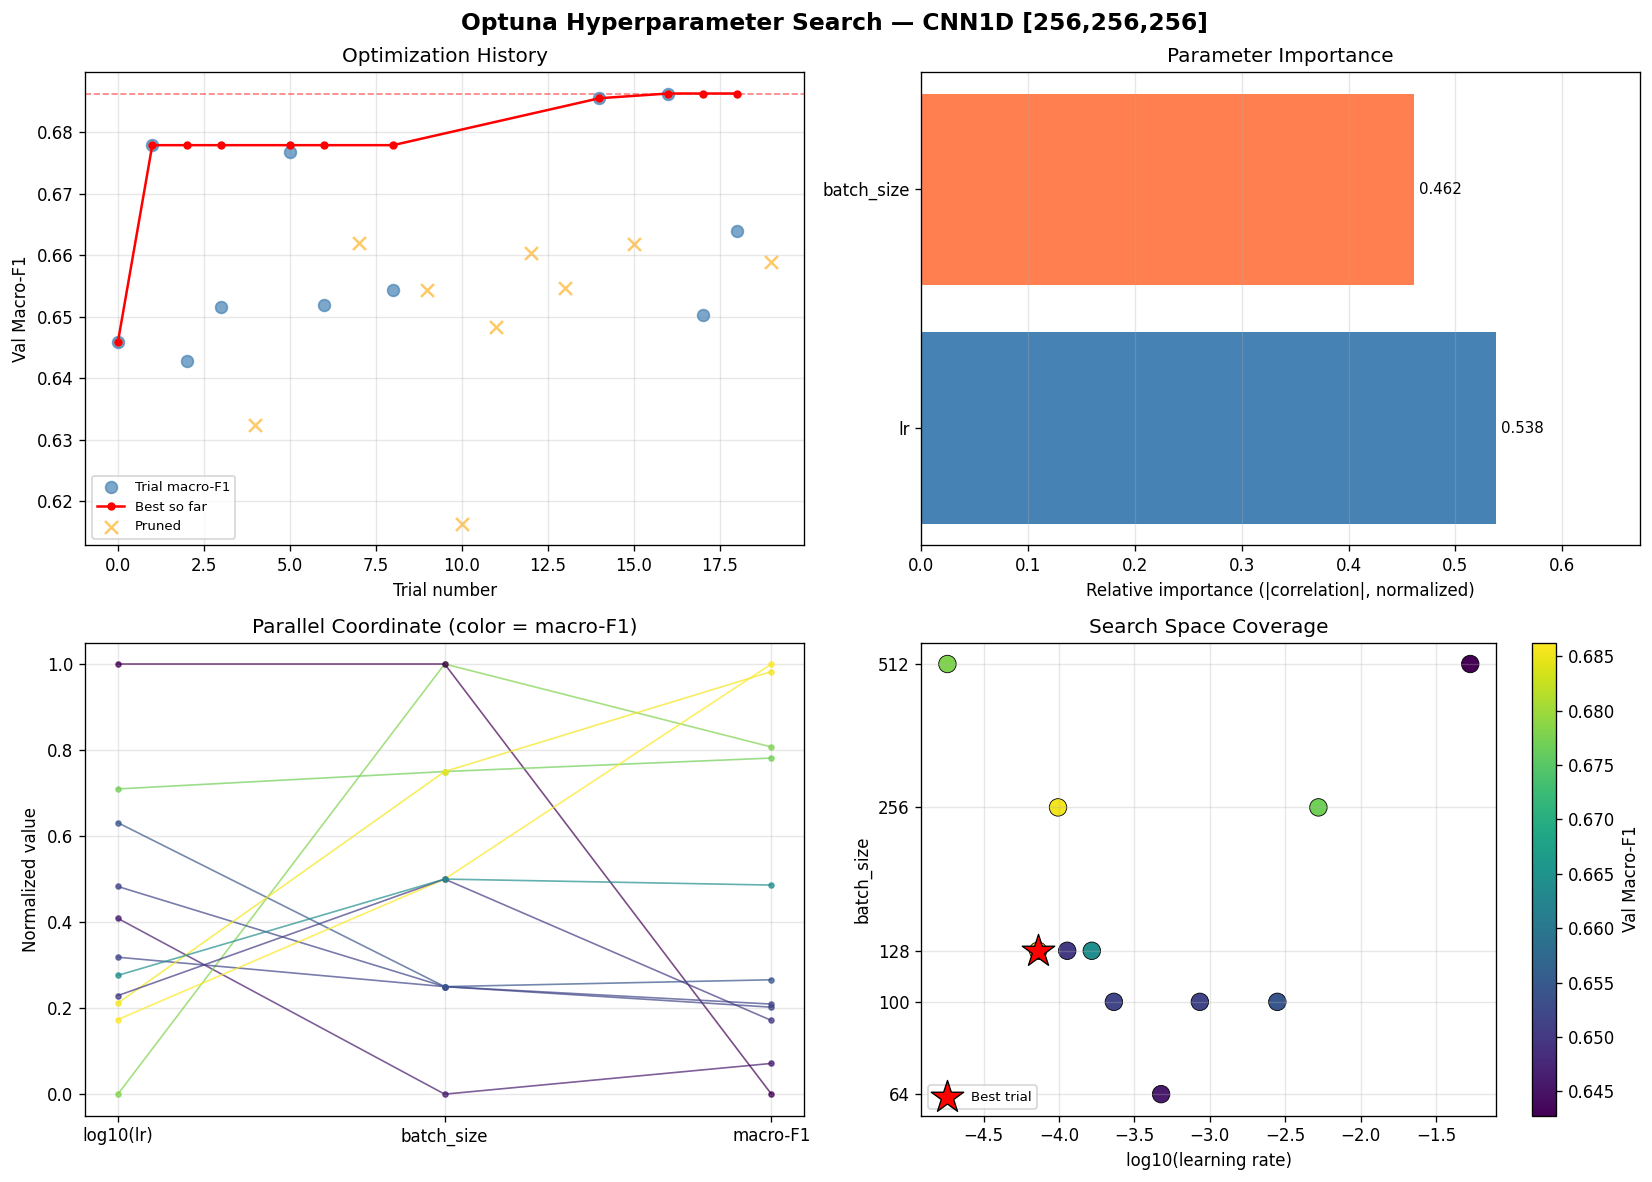

  Optuna plots saved: /kaggle/working/optuna_search.png

  TẤT CẢ TRIALS
    #  state               lr   batch    macro-F1
--------------------------------------------------------------------------
    0  COMPLETE     4.752e-04      64    0.645869
    1  COMPLETE     1.820e-05     512    0.677870
    2  COMPLETE     5.333e-02     512    0.642761
    3  COMPLETE     8.588e-04     100    0.651556
    4  PRUNED       1.101e-03      64    0.632333
    5  COMPLETE     5.249e-03     256    0.676750
    6  COMPLETE     2.311e-04     100    0.651871
    7  PRUNED       1.425e-05      64    0.661949
    8  COMPLETE     2.803e-03     100    0.654328
    9  PRUNED       4.752e-03      64    0.654324
   10  PRUNED       1.834e-01     512    0.616369
   11  PRUNED       1.081e-05     256    0.648254
   12  PRUNED       5.680e-05     256    0.660397
   13  PRUNED       2.136e-02     128    0.654595
   14  COMPLETE     9.850e-05     256    0.685495
   15  PRUNED       5.786e-05     512    0.661745
  

In [6]:
# ── GUARD: chỉ chạy khi Optuna đã đủ trials ───────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 5 — TRỰC QUAN HÓA OPTUNA ─────────────────────
    completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    pruned_trials    = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]

    print(f'Completed trials : {len(completed_trials)}')
    print(f'Pruned trials    : {len(pruned_trials)}')
    print(f'Best trial       : #{study.best_trial.number}  macro-F1={best_val_macro_f1_optuna:.6f}')

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Optuna Hyperparameter Search — CNN1D [256,256,256]',
                 fontsize=14, fontweight='bold')

    # ── Optimization History ────────────────────────────────
    ax = axes[0, 0]
    trial_numbers = [t.number for t in completed_trials]
    f1_values     = [t.value  for t in completed_trials]
    best_so_far   = [max(f1_values[:i+1]) for i in range(len(f1_values))]
    ax.scatter(trial_numbers, f1_values, c='steelblue', s=50, alpha=0.7, zorder=3, label='Trial macro-F1')
    ax.plot(trial_numbers, best_so_far, 'r-o', markersize=4, linewidth=1.5, label='Best so far', zorder=4)
    if pruned_trials:
        _pn = [t.number for t in pruned_trials if t.intermediate_values]
        _pv = [t.intermediate_values[max(t.intermediate_values)] for t in pruned_trials if t.intermediate_values]
        if _pn:
            ax.scatter(_pn, _pv, c='orange', marker='x', s=60, alpha=0.6, label='Pruned')
    ax.axhline(best_val_macro_f1_optuna, color='red', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Trial number')
    ax.set_ylabel('Val Macro-F1')
    ax.set_title('Optimization History')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    # ── Parameter Importance ────────────────────────────────
    ax = axes[0, 1]
    param_names = ['lr', 'batch_size']
    importances = []
    for p in param_names:
        vals = np.array([t.params[p] for t in completed_trials], dtype=float)
        if p == 'lr':
            vals = np.log10(vals)
        elif p == 'batch_size':
            vals = np.array([OPTUNA_BS_CHOICES.index(int(v)) for v in vals], dtype=float)
        objs = np.array(f1_values, dtype=float)
        if len(vals) > 1 and np.std(vals) > 0 and np.std(objs) > 0:
            corr = abs(np.corrcoef(vals, objs)[0, 1])
        else:
            corr = 0.0
        importances.append(0.0 if np.isnan(corr) else corr)

    tot = sum(importances)
    importances = [i / tot for i in importances] if tot > 0 else [0.0] * len(param_names)
    bars = ax.barh(param_names, importances, color=['steelblue', 'coral'])
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_xlabel('Relative importance (|correlation|, normalized)')
    ax.set_title('Parameter Importance')
    ax.set_xlim(0, max(importances + [0.1]) * 1.25)
    ax.grid(True, alpha=0.3, axis='x')

    # ── Parallel coordinate ──────────────────────────────────
    ax = axes[1, 0]
    if completed_trials:
        lrs = np.log10([t.params['lr'] for t in completed_trials])
        bss = np.array([OPTUNA_BS_CHOICES.index(int(t.params['batch_size'])) for t in completed_trials], dtype=float)
        f1s = np.array(f1_values)
        def _norm(a):
            rng = a.max() - a.min()
            return (a - a.min()) / rng if rng > 0 else np.full_like(a, 0.5)
        cols = [_norm(lrs), _norm(bss), _norm(f1s)]
        xs = [0, 1, 2]
        cmap = plt.cm.viridis
        f1n = _norm(f1s)
        for i in range(len(completed_trials)):
            ax.plot(xs, [c[i] for c in cols], '-o', markersize=3, color=cmap(f1n[i]), alpha=0.7, linewidth=1)
        ax.set_xticks(xs)
        ax.set_xticklabels(['log10(lr)', 'batch_size', 'macro-F1'])
        ax.set_ylabel('Normalized value')
        ax.set_title('Parallel Coordinate (color = macro-F1)')
        ax.grid(True, alpha=0.3)

    # ── Scatter lr x batch_size ─────────────────────────────
    ax = axes[1, 1]
    if completed_trials:
        sc = ax.scatter(np.log10([t.params['lr'] for t in completed_trials]),
                        [t.params['batch_size'] for t in completed_trials],
                        c=f1_values, cmap='viridis', s=110, edgecolors='k', linewidths=0.5)
        bt = study.best_trial
        ax.scatter(np.log10(bt.params['lr']), bt.params['batch_size'],
                   marker='*', s=420, c='red', edgecolors='k', linewidths=0.8, label='Best trial', zorder=5)
        plt.colorbar(sc, ax=ax, label='Val Macro-F1')
        ax.set_xlabel('log10(learning rate)')
        ax.set_ylabel('batch_size')
        ax.set_yscale('log', base=2)
        ax.set_yticks(OPTUNA_BS_CHOICES)
        ax.set_yticklabels(OPTUNA_BS_CHOICES)
        ax.set_title('Search Space Coverage')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    optuna_plot_path = os.path.join(OUTPUT_DIR, 'optuna_search.png')
    plt.savefig(optuna_plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Optuna plots saved: {optuna_plot_path}')

    # ── Bảng tóm tắt tất cả trials ──────────────────────────
    print('\n' + '=' * 74)
    print('  TẤT CẢ TRIALS')
    print('=' * 74)
    print(f"  {'#':>3}  {'state':<9} {'lr':>12} {'batch':>7} {'macro-F1':>11}")
    print('-' * 74)
    for t in study.trials:
        v    = f'{t.value:.6f}' if t.value is not None else '—'
        lr_s = f"{t.params['lr']:.3e}" if 'lr' in t.params else '—'
        bs_s = t.params.get('batch_size', '—')
        star = '  ←BEST' if (t.state == optuna.trial.TrialState.COMPLETE and t.number == study.best_trial.number) else ''
        print(f'  {t.number:>3}  {t.state.name:<9} {lr_s:>12} {str(bs_s):>7} {v:>11}{star}')
    print('=' * 74)

In [7]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 6 — TRAIN CHÍNH THỨC VỚI BEST PARAMS ────────
    with open(f"{OUTPUT_DIR}best_params.json", "r") as f:
        best_params = json.load(f)
    BEST_LR         = best_params['lr']
    BEST_BATCH_SIZE = best_params['batch_size']

    MODEL_PATH = f"{OUTPUT_DIR}best_model_50epoch.keras"

    print('=' * 58)
    print('  TRAIN CHÍNH THỨC — CNN1D [256,256,256]')
    print(f'  Batch={BEST_BATCH_SIZE}, LR={BEST_LR:.6f}')
    print(f'  MaxEpoch={FINAL_MAX_EPOCHS}  (KHÔNG EarlyStopping)')
    print('  Lưu best epoch theo val loss thấp nhất')
    print('=' * 58)

    K.clear_session()
    tf.random.set_seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)
    model = build_cnn1d_model(BEST_LR, (NUM_FEATURES, 1), NUM_CLASSES)
    print('  Model khởi tạo random (train từ đầu).')

    checkpoint = callbacks.ModelCheckpoint(
        MODEL_PATH,
        monitor='val_loss',
        mode='min',
        save_best_only=True,
        verbose=1
    )

    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=BEST_BATCH_SIZE,
        epochs=FINAL_MAX_EPOCHS,
        validation_data=(X_val, y_val),
        callbacks=[checkpoint],
        verbose=1
    )
    train_time = time.time() - start_time

    hist          = history.history
    best_epoch    = int(np.argmin(hist['val_loss'])) + 1
    best_val_loss = float(np.min(hist['val_loss']))

    model = tf.keras.models.load_model(MODEL_PATH)

    with open(f"{OUTPUT_DIR}train_time.txt", "w") as f:
        f.write(str(train_time))

    print(f'\n==> Training done. {train_time:.1f}s ({train_time/60:.1f} phút)')
    print(f'    Best epoch : {best_epoch}/{FINAL_MAX_EPOCHS}  |  Best val loss : {best_val_loss:.6f}')
    print(f'    Model tốt nhất được lưu tại: {MODEL_PATH}')

  TRAIN CHÍNH THỨC — CNN1D [256,256,256]
  Batch=128, LR=0.000073
  MaxEpoch=50  (KHÔNG EarlyStopping)
  Lưu best epoch theo val loss thấp nhất
  Model khởi tạo random (train từ đầu).
Epoch 1/50
34909/34909 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8028 - loss: 0.4517
Epoch 1: val_loss improved from None to 0.37672, saving model to /kaggle/working/best_model_50epoch.keras

Epoch 1: finished saving model to /kaggle/working/best_model_50epoch.keras
34909/34909 ━━━━━━━━━━━━━━━━━━━━ 191s 5ms/step - accuracy: 0.8168 - loss: 0.4116 - val_accuracy: 0.8301 - val_loss: 0.3767
Epoch 2/50
34904/34909 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8310 - loss: 0.3727
Epoch 2: val_loss improved from 0.37672 to 0.36613, saving model to /kaggle/working/best_model_50epoch.keras

Epoch 2: finished saving model to /kaggle/working/best_model_50epoch.keras
34909/34909 ━━━━━━━━━━━━━━━━━━━━ 181s 5ms/step - accuracy: 0.8328 - loss: 0.3687 - val_accuracy: 0.8336 - val_loss: 0.3661
Epoch 3/50
34909/34909 

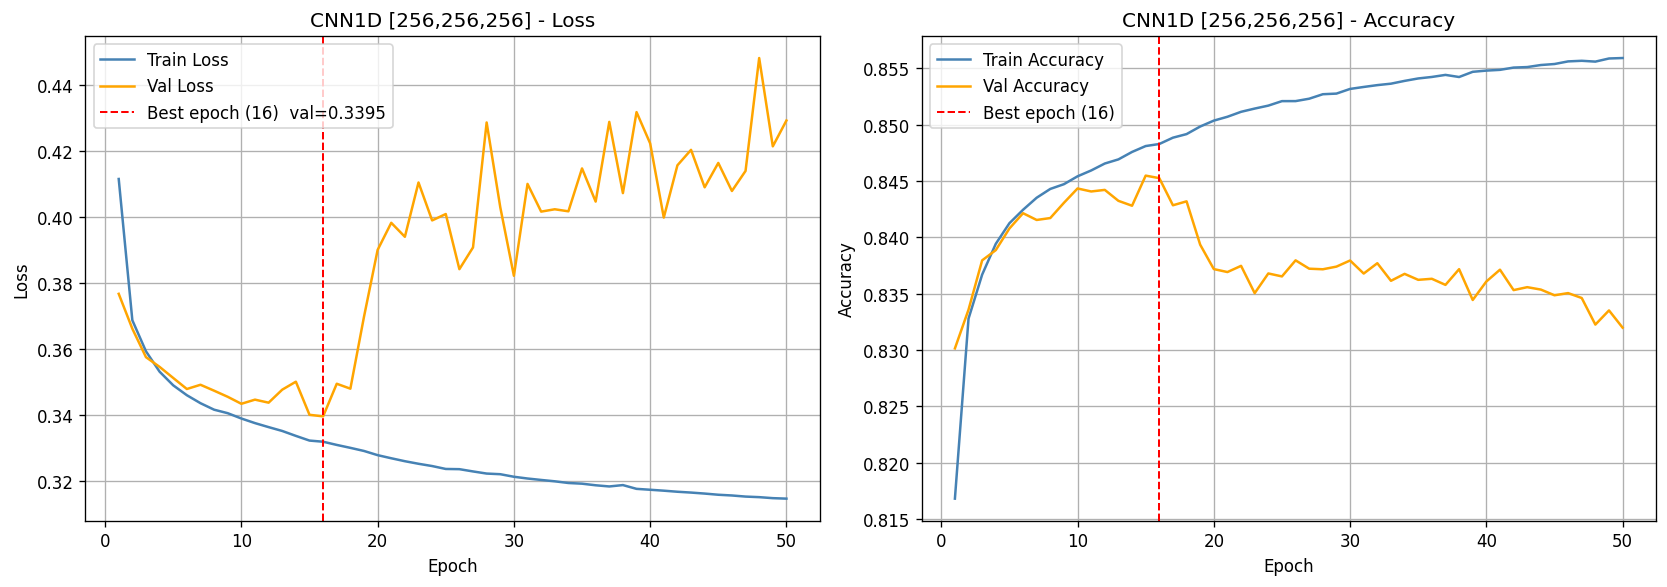

✅ Đã lưu biểu đồ training curves.


In [8]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 7 — Biểu đồ training curves ──────────────────
    hist = history.history
    epochs_range = range(1, len(hist['loss']) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, hist['loss'], label='Train Loss', color='steelblue')
    axes[0].plot(epochs_range, hist['val_loss'], label='Val Loss', color='orange')
    axes[0].axvline(best_epoch, color='red', linestyle='--', linewidth=1.2,
                    label=f'Best epoch ({best_epoch})  val={best_val_loss:.4f}')
    axes[0].set_title('CNN1D [256,256,256] - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs_range, hist['accuracy'], label='Train Accuracy', color='steelblue')
    axes[1].plot(epochs_range, hist['val_accuracy'], label='Val Accuracy', color='orange')
    axes[1].axvline(best_epoch, color='red', linestyle='--', linewidth=1.2,
                    label=f'Best epoch ({best_epoch})')
    axes[1].set_title('CNN1D [256,256,256] - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}training_curves.png", dpi=150)
    plt.show()
    print("✅ Đã lưu biểu đồ training curves.")

10910/10910 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
===== Classification Report =====
              precision    recall  f1-score   support

           0     0.7642    0.9025    0.8276    209448
           1     0.8587    0.9423    0.8986    598978
           2     0.7461    0.5215    0.6139    193688
           3     0.8372    0.2464    0.3807      2504
           4     0.9161    0.7323    0.8140     87173
           5     0.7725    0.6804    0.7235    119826
           6     0.5568    0.1076    0.1803      4741
           7     0.9989    0.9960    0.9975    180000

    accuracy                         0.8452   1396358
   macro avg     0.8063    0.6411    0.6795   1396358
weighted avg     0.8421    0.8452    0.8375   1396358


Accuracy      : 0.8452
Macro F1      : 0.6795
Weighted F1   : 0.8375


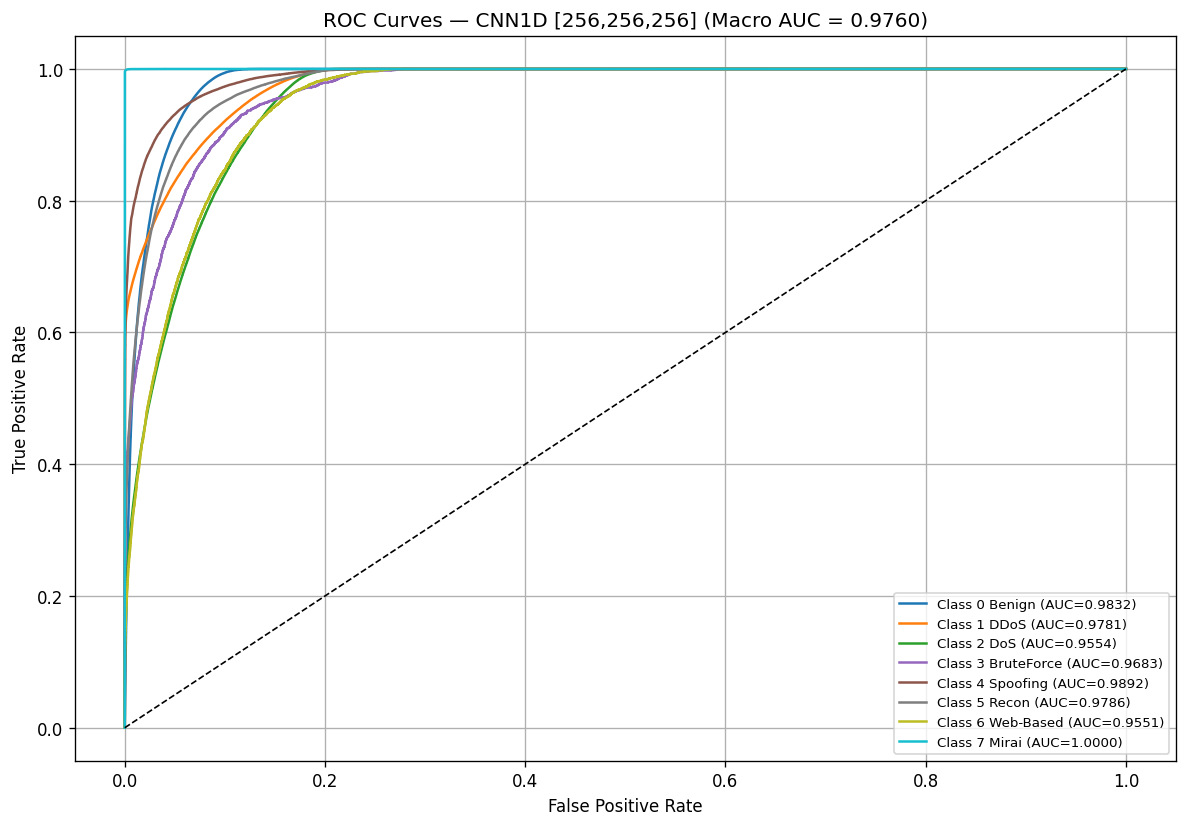

Macro AUC: 0.9760


In [9]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 8 — Đánh giá trên tập test ─────────────────────
    best_model = tf.keras.models.load_model(MODEL_PATH)

    y_proba = best_model.predict(X_test, batch_size=128, verbose=1)
    y_pred = np.argmax(y_proba, axis=1)

    report = classification_report(y_test, y_pred, digits=4, zero_division=0)
    print("===== Classification Report =====")
    print(report)
    with open(f"{OUTPUT_DIR}classification_report.txt", "w") as f:
        f.write(report)

    acc = accuracy_score(y_test, y_pred)
    prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
        y_test, y_pred, average='macro', zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0)

    print(f"\nAccuracy      : {acc:.4f}")
    print(f"Macro F1      : {f1_macro:.4f}")
    print(f"Weighted F1   : {f1_weighted:.4f}")

    metrics = {
        'accuracy': acc,
        'macro_f1': f1_macro,
        'weighted_f1': f1_weighted,
        'macro_precision': prec_macro,
        'macro_recall': rec_macro,
        'best_epoch': best_epoch,
        'best_val_loss': best_val_loss,
        'best_lr': BEST_LR,
        'best_batch_size': BEST_BATCH_SIZE,
        'optuna_best_val_macro_f1': float(best_val_macro_f1_optuna),
    }
    with open(f"{OUTPUT_DIR}test_metrics.json", "w") as f:
        json.dump(metrics, f, indent=4)

    # ── ROC Curves & AUC ────────────────────────────────────
    y_test_bin = label_binarize(y_test, classes=range(NUM_CLASSES))
    plt.figure(figsize=(10, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, NUM_CLASSES))
    auc_scores = []
    for i, color in enumerate(colors):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        auc_val = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
        auc_scores.append(auc_val)
        plt.plot(fpr, tpr, color=color, lw=1.5,
                 label=f'Class {i} {LABEL_NAMES.get(i, "")} (AUC={auc_val:.4f})')
    macro_auc = np.mean(auc_scores)
    plt.plot([0, 1], [0, 1], 'k--', lw=1)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curves — CNN1D [256,256,256] (Macro AUC = {macro_auc:.4f})')
    plt.legend(loc='lower right', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}roc_curves.png", dpi=150)
    plt.show()
    print(f"Macro AUC: {macro_auc:.4f}")
    with open(f"{OUTPUT_DIR}macro_auc.txt", "w") as f:
        f.write(str(macro_auc))

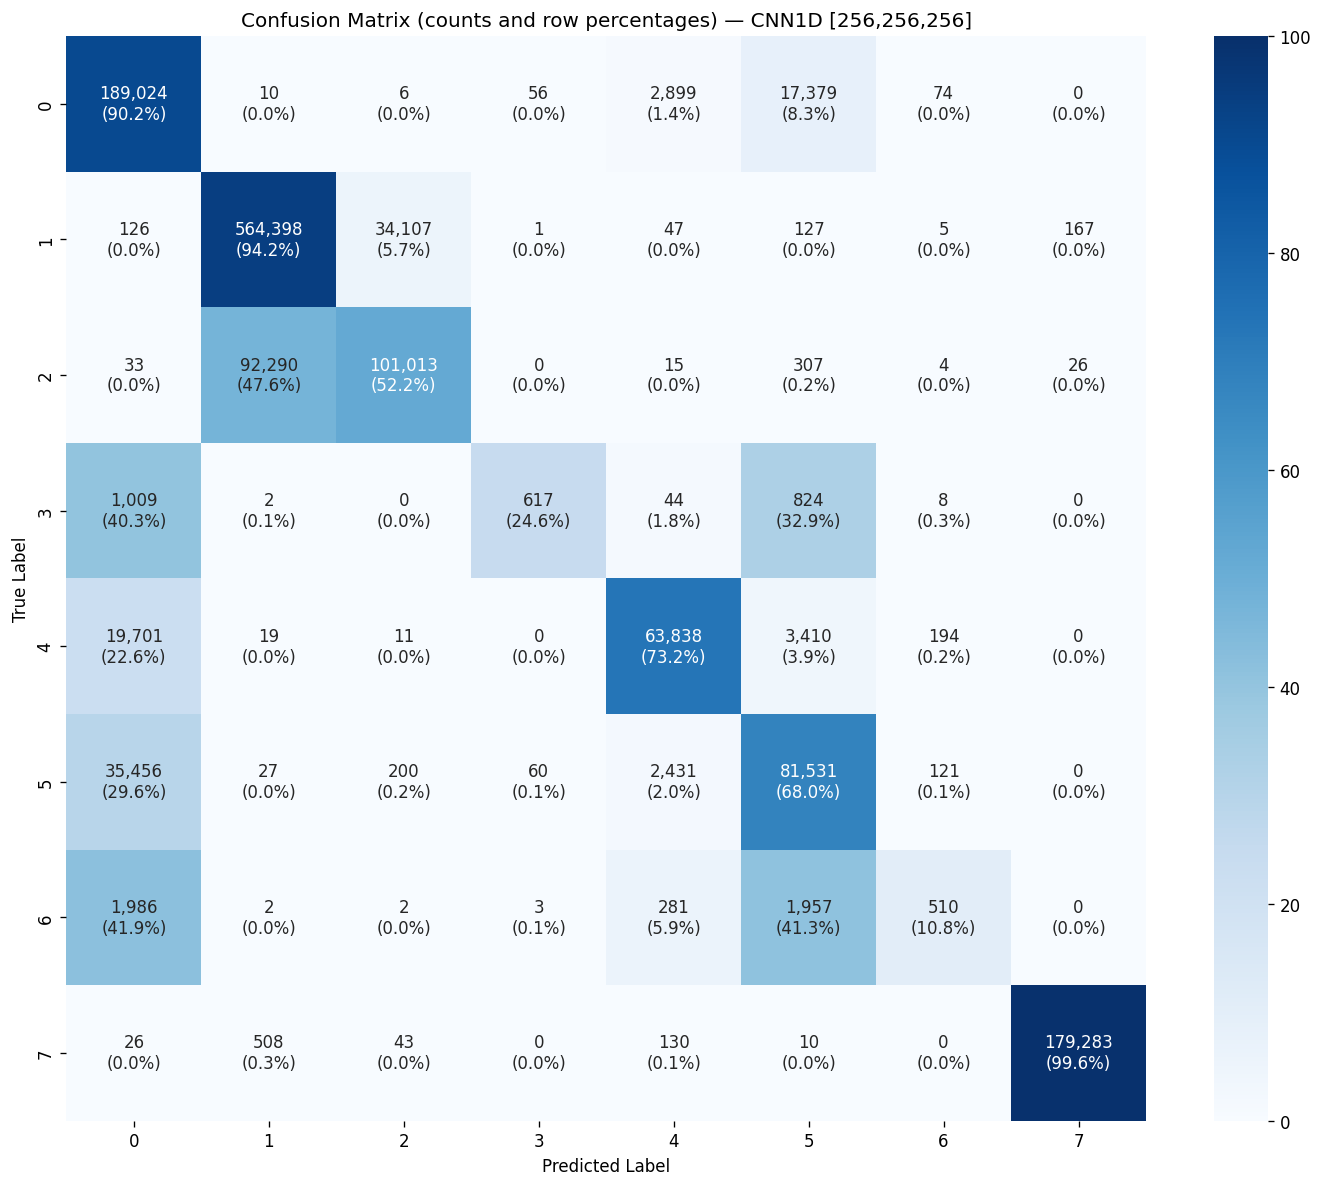

✅ Đã lưu confusion matrix.


In [10]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 9 — Confusion Matrix ──────────────────────────
    cm = confusion_matrix(y_test, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    annot = np.empty_like(cm, dtype=object)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)"

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_pct, annot=annot, fmt='', cmap='Blues',
                xticklabels=range(NUM_CLASSES),
                yticklabels=range(NUM_CLASSES),
                vmin=0, vmax=100)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix (counts and row percentages) — CNN1D [256,256,256]')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}confusion_matrix.png", dpi=150)
    plt.show()
    print("✅ Đã lưu confusion matrix.")

In [11]:
# ── GUARD ─────────────────────────────────────────────────
if not globals().get('PIPELINE_CONTINUE', True):
    print('⏭ BỎ QUA cell này — Optuna chưa đủ trials.')
else:
    # ── CELL 10 — Heaviness Metrics ────────────────────────
    model_path = MODEL_PATH
    size_bytes = os.path.getsize(model_path)
    size_mb = size_bytes / (1024 * 1024)

    total_params = best_model.count_params()
    trainable_params = sum(tf.keras.backend.count_params(w) for w in best_model.trainable_weights)

    for _ in range(5):
        best_model.predict(X_test[:100], batch_size=128, verbose=0)
    N = 2000
    t0 = time.perf_counter()
    best_model.predict(X_test[:N], batch_size=128, verbose=0)
    inf_time_per_sample = (time.perf_counter() - t0) * 1000 / N

    heaviness = {
        "model_size_mb": round(size_mb, 6),
        "total_params": int(total_params),
        "trainable_params": int(trainable_params),
        "train_time_s": round(train_time, 4),
        "inference_ms_per_sample": round(inf_time_per_sample, 6)
    }
    print("===== Heaviness Metrics =====")
    for k, v in heaviness.items():
        print(f"  {k:<25s}: {v}")
    with open(f"{OUTPUT_DIR}heaviness.json", "w") as f:
        json.dump(heaviness, f, indent=4)

    # ── Tổng kết file đã xuất ────────────────────────────────
    print()
    print('=' * 58)
    print('  FILE ĐÃ XUẤT TRONG', OUTPUT_DIR)
    print('=' * 58)
    for fn in sorted(os.listdir(OUTPUT_DIR)):
        fp = os.path.join(OUTPUT_DIR, fn)
        if os.path.isfile(fp):
            print(f"  {fn:<40} {os.path.getsize(fp)/1024:>10.1f} KB")
    print('=' * 58)

===== Heaviness Metrics =====
  model_size_mb            : 4.696061
  total_params             : 406024
  trainable_params         : 404488
  train_time_s             : 9098.1275
  inference_ms_per_sample  : 0.234018

  FILE ĐÃ XUẤT TRONG /kaggle/working/
  __notebook__.ipynb                          68986.8 KB
  best_model_50epoch.keras                     4808.8 KB
  best_params.json                                0.1 KB
  classification_report.txt                       0.6 KB
  confusion_matrix.png                          176.1 KB
  heaviness.json                                  0.2 KB
  macro_auc.txt                                   0.0 KB
  metadata.json                                   0.8 KB
  optuna_search.png                             270.7 KB
  optuna_study_cnn1d_37ft.pkl                    22.5 KB
  roc_curves.png                                143.6 KB
  test_metrics.json                               0.4 KB
  train_time.txt                                  0.0 KB
  t